<a href="https://colab.research.google.com/github/Shailesh0403/-https-github.com-shailesh0304-ctrl-HackSprint-Automation-Dashboard/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
#PROJECT TITLE
print("======================================")
print(" TITANIC SURVIVAL PREDICTION PROJECT ")
print(" USING LOGISTIC REGRESSION ")
print("======================================")

 TITANIC SURVIVAL PREDICTION PROJECT 
 USING LOGISTIC REGRESSION 


In [50]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [51]:
# Upload Titanic CSV File

uploaded = files.upload()

# Confirm which file was uploaded
if uploaded:
    for filename in uploaded.keys():
        print(f"File '{filename}' uploaded successfully.")
else:
    print("No file was uploaded.")

Saving titanic.csv to titanic (2).csv
File 'titanic (2).csv' uploaded successfully.


In [52]:
# Read CSV file

df = pd.read_csv("titanic.csv")

# Display first 5 rows

df.head()

,survived,pclass,name,sex,age,fare,sibsp,parch
0,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,1,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,1,0
2,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,0,0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,1,0
4,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,0,0


In [53]:
# Dataset Information

print("Dataset Information")
print(df.info())

print("\n")

print("Dataset Shape")
print(df.shape)

print("\n")

print("Statistical Summary")
print(df.describe())

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  714 non-null    int64  
 1   pclass    714 non-null    int64  
 2   name      714 non-null    object 
 3   sex       714 non-null    object 
 4   age       714 non-null    float64
 5   fare      714 non-null    float64
 6   sibsp     714 non-null    int64  
 7   parch     714 non-null    int64  
dtypes: float64(2), int64(4), object(2)
memory usage: 44.8+ KB
None


Dataset Shape
(714, 8)


Statistical Summary
         survived      pclass         age        fare       sibsp       parch
count  714.000000  714.000000  714.000000  714.000000  714.000000  714.000000
mean     0.406162    2.236695   29.699118   34.694514    0.512605    0.431373
std      0.491460    0.838250   14.526497   52.918930    0.929783    0.853289
min      0.000000    1.000000    0.420000    0.000000    0.

In [54]:
# Check missing values

print(df.isnull().sum())

survived    0
pclass      0
name        0
sex         0
age         0
fare        0
sibsp       0
parch       0
dtype: int64


In [55]:
#HANDLE MISSING VALUES
df['age'] = df['age'].fillna(df['age'].median())

print("Missing Values After Cleaning")

print(df.isnull().sum())

Missing Values After Cleaning
survived    0
pclass      0
name        0
sex         0
age         0
fare        0
sibsp       0
parch       0
dtype: int64


In [56]:
#CONVERT CATEGORICAL DATA

# Convert male/female into numbers
# Only apply mapping if the column is of object type (contains strings)
if df['sex'].dtype == 'object':
    df['sex'] = df['sex'].map({
        'male': 0,
        'female': 1
    })

print(df.head())

   survived  pclass                                               name  sex  \
0         0       3                            Braund, Mr. Owen Harris    0   
1         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1   
2         1       3                             Heikkinen, Miss. Laina    1   
3         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1   
4         0       3                           Allen, Mr. William Henry    0   

    age     fare  sibsp  parch  
0  22.0   7.2500      1      0  
1  38.0  71.2833      1      0  
2  26.0   7.9250      0      0  
3  35.0  53.1000      1      0  
4  35.0   8.0500      0      0  


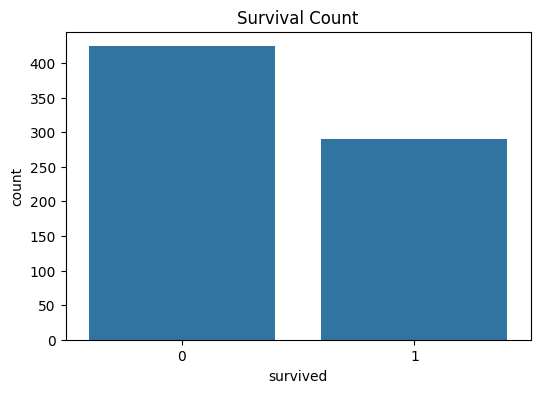

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(x='survived', data=df)

plt.title("Survival Count")

plt.show()

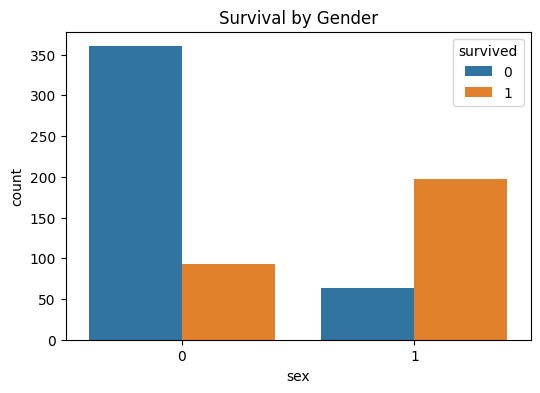

In [58]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', hue='survived', data=df)

plt.title("Survival by Gender")

plt.show()

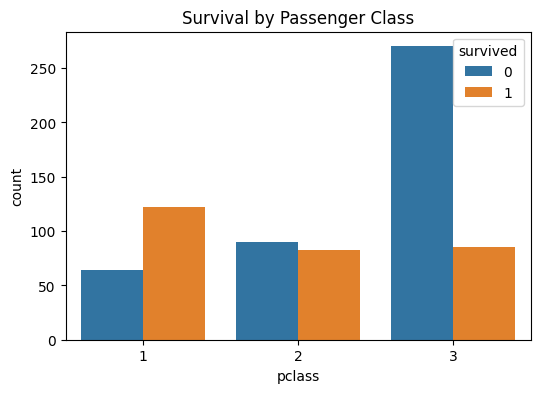

In [59]:
plt.figure(figsize=(6,4))

sns.countplot(x='pclass', hue='survived', data=df)

plt.title("Survival by Passenger Class")

plt.show()

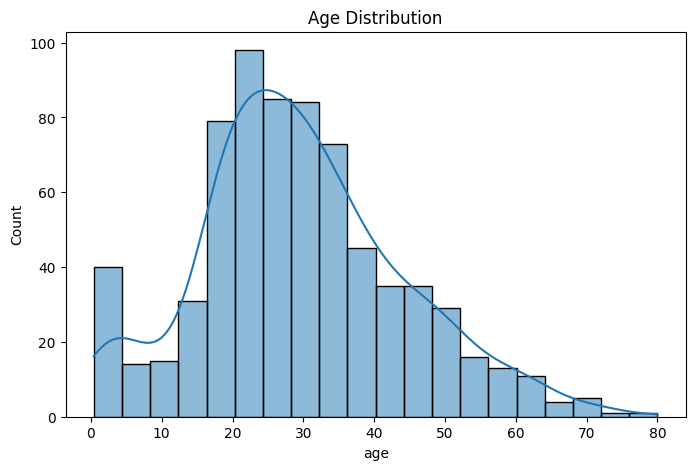

In [60]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.show()

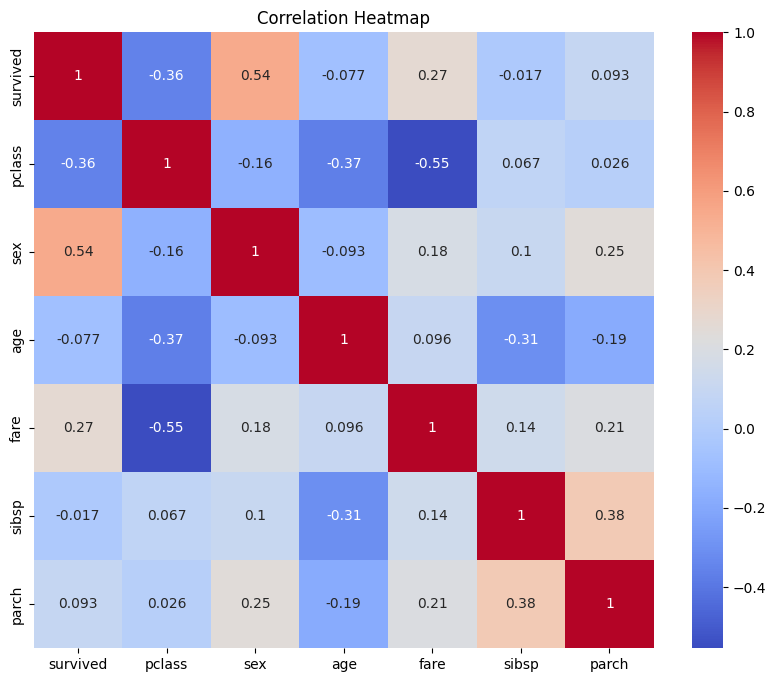

In [61]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [62]:
# Input Features

X = df[['pclass', 'sex', 'age', 'fare']]

# Target Variable

y = df['survived']

print(X.head())

print(y.head())

   pclass  sex   age     fare
0       3    0  22.0   7.2500
1       1    1  38.0  71.2833
2       3    1  26.0   7.9250
3       1    1  35.0  53.1000
4       3    0  35.0   8.0500
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Size:", X_train.shape)

print("Testing Data Size:", X_test.shape)

Training Data Size: (571, 4)
Testing Data Size: (143, 4)


In [64]:
# Create model

model = LogisticRegression(max_iter=200)

# Train model

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [65]:
# Predict values

y_pred = model.predict(X_test)

print(y_pred[:10])

[0 1 1 1 0 0 1 1 1 1]


In [66]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy of Logistic Regression Model")

print(accuracy)

Accuracy of Logistic Regression Model
0.7552447552447552


In [67]:
# Create Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[68 19]
 [16 40]]


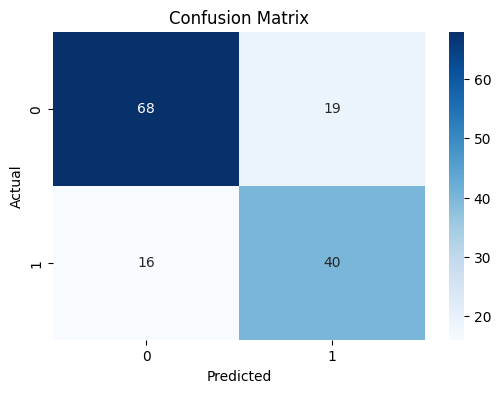

In [68]:
plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [69]:
# Print Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.78      0.80        87
           1       0.68      0.71      0.70        56

    accuracy                           0.76       143
   macro avg       0.74      0.75      0.75       143
weighted avg       0.76      0.76      0.76       143



In [70]:
# Example Passenger

# Pclass = 1
# Sex = Female (1)
# Age = 25
# Fare = 100

sample_passenger = [[1, 1, 25, 100]]

prediction = model.predict(sample_passenger)

if prediction[0] == 1:
    print("Passenger Survived")
else:
    print("Passenger Did Not Survive")

Passenger Survived


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [71]:
print("\nModel Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

print(f"\nModel Intercept: {model.intercept_[0]:.4f}")


Model Coefficients:
pclass: -1.2407
sex: 2.5305
age: -0.0425
fare: 0.0002

Model Intercept: 2.6117


In [72]:
print("===================================")
print(" PROJECT COMPLETED SUCCESSFULLY ")
print(" TITANIC SURVIVAL PREDICTION ")
print(" USING LOGISTIC REGRESSION ")
print("===================================")

 PROJECT COMPLETED SUCCESSFULLY 
 TITANIC SURVIVAL PREDICTION 
 USING LOGISTIC REGRESSION 
